In [1]:
#Requirements
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,BatchNormalization,Dropout,Input
from keras.regularizers import l2
from keras.initializers import HeNormal

In [5]:
classes=sorted(os.listdir(r'Train'))

In [3]:
#Data loading and preprocessing
data_gen=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    shear_range=0.1,
    validation_split=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    rotation_range=20
)

train_data=data_gen.flow_from_directory(
    r'Train',
    target_size=(32,32),
    batch_size=64,
    subset='training',
    color_mode='grayscale'
)

val_data=data_gen.flow_from_directory(
    r'Validation',
    target_size=(32,32),
    batch_size=64,
    subset='validation',
    color_mode='grayscale'
)

Found 667244 images belonging to 39 classes.
Found 4492 images belonging to 39 classes.


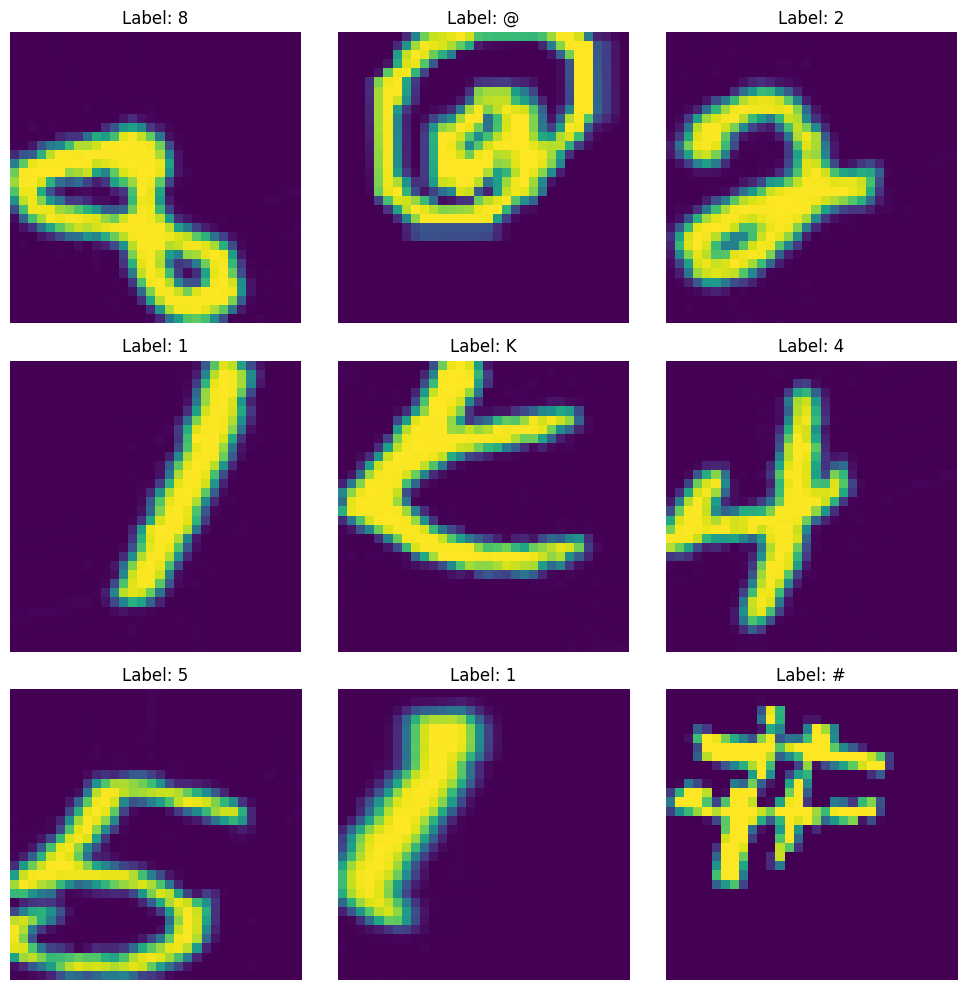

In [6]:
#Lets see the images
images, labels = next(train_data)

# Plot the first few images
plt.figure(figsize=(10, 10))
for i in range(9):  # Display first 9 images
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {classes[np.argmax(labels[i])]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#Model
model=Sequential([
    Input(shape=(32,32,1)),
    
    Conv2D(16,(3,3),padding='same',activation='relu',kernel_initializer=HeNormal(),kernel_regularizer=l2(1e-3)),
    Conv2D(16,(3,3),padding='same',activation='relu',kernel_initializer=HeNormal(),kernel_regularizer=l2(1e-3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(32,(3,3),padding='same',activation='relu',kernel_initializer=HeNormal(),kernel_regularizer=l2(1e-3)),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(32,activation='relu',kernel_regularizer=l2(1e-4)),
    Dense(39,activation='softmax')
])

#Compile
model.compile(optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

#Fitting(Training)
history=model.fit(train_data,epochs=20,validation_data=val_data,callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True,verbose=1,start_from_epoch=5)])

In [ ]:
#Saving
model.save('characters.keras')

In [ ]:
#Model performance
plt.plot(history.history['loss'],label='Loss')
plt.plot(history.history['val_loss'],label='Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Accuracy')
plt.legend()
plt.show()

In [ ]:
#Testing
model = tf.keras.models.load_model('characters.keras')

img_path = r''
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(32, 32))  # Resize image to match the model input size

# Convert the image to a numpy array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# Add an extra dimension (batch size of 1) as the model expects input in batches
img_array = np.expand_dims(img_array, axis=0)

# Normalize the image (if you did normalization during training, e.g., rescaling)
img_array = img_array / 255.0  # Assuming you scaled the images to [0,1] during training

# Predict the class of the image
predictions = model.predict(img_array)

# Get the predicted class index (for multi-class, you can get the index with the highest probability)
predicted_class_index = np.argmax(predictions, axis=1)

# Print the predicted class index (you can map this to the category name if needed)
print(f"Predicted Class Index: {classes[predicted_class_index]}")
